In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import keras.models
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns



In [3]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns


def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values



# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y


# load the dataset, returns train and test X and y elements
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/Users/ohheungchan/workspace/AI_Study/Paperwork/human+activity+recognition+using+smartphones/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/Users/ohheungchan/workspace/AI_Study/Paperwork/human+activity+recognition+using+smartphones/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1

    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

In [4]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()


/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whit

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_65597/1700422476.py:9: FutureWarning: The 'delim_whit

In [5]:
print("X train shape: ", trainX.shape)
print("Y train shape: ", trainy.shape)
print("Y train One hot shape: ", trainy_one_hot.shape)
print("X test shape: ", testX.shape)
print("Y test shape: ", testy.shape)
print("Y test One hot shape: ", testy_one_hot.shape)

X train shape:  (7352, 128, 9)
Y train shape:  (7352, 1)
Y train One hot shape:  (7352, 6)
X test shape:  (2947, 128, 9)
Y test shape:  (2947, 1)
Y test One hot shape:  (2947, 6)


In [6]:
print("0: Walking:" ,np.where(trainy == 0)[0].size)
print("1: WU:" ,np.where(trainy == 1)[0].size)
print("2: WD:" ,np.where(trainy == 2)[0].size)
print("3: Sitting:" ,np.where(trainy == 3)[0].size)
print("4: Standing:" ,np.where(trainy == 4)[0].size)
print("5: Laying:" ,np.where(trainy == 5)[0].size)

0: Walking: 1226
1: WU: 1073
2: WD: 986
3: Sitting: 1286
4: Standing: 1374
5: Laying: 1407


In [7]:
unique, counts = np.unique(trainy, return_counts=True)
print ("Train data label statistics::")
print (np.asarray((unique, counts)).T)

unique, counts = np.unique(testy, return_counts=True)
print ("Test data label statistics::")
print (np.asarray((unique, counts)).T)

Train data label statistics::
[[   0 1226]
 [   1 1073]
 [   2  986]
 [   3 1286]
 [   4 1374]
 [   5 1407]]
Test data label statistics::
[[  0 496]
 [  1 471]
 [  2 420]
 [  3 491]
 [  4 532]
 [  5 537]]


In [8]:
X_train_all = trainX   # at this stage, the data includes both dynamic and static HAR data
y_train_all = trainy

X_test_all = testX
y_test_all = testy

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
import math

# Device 설정
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# --- DataEmbedding ---
class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding, self).__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, x_mark):
        x = self.value_embedding(x)
        return self.dropout(x)

# --- Inception_Block_V2 (Improved Version) ---
class Inception_Block_V2(nn.Module):
    def __init__(self, in_channels, out_channels, num_kernels=3):
        super(Inception_Block_V2, self).__init__()
        kernel_sizes = [3, 5, 7][:num_kernels]
        self.conv_branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=(1, k), padding=(0, k // 2)),
                nn.BatchNorm2d(out_channels),
                nn.GELU()
            ) for k in kernel_sizes
        ])
        self.fusion = nn.Conv2d(out_channels, out_channels, kernel_size=1)

    def forward(self, x):
        outputs = [branch(x) for branch in self.conv_branches]
        out = sum(outputs) / len(outputs)  # average instead of sum
        return self.fusion(out)

# --- FFT_for_Period ---
def FFT_for_Period(x, k=2):
    xf = torch.fft.rfft(x, dim=1)
    frequency_list = abs(xf).mean(0).mean(-1)
    frequency_list[0] = 0
    _, top_list = torch.topk(frequency_list, k)
    top_list = top_list.detach().cpu().numpy()
    period = x.shape[1] // top_list
    return period, abs(xf).mean(-1)[:, top_list]

# --- TimesBlock (Improved) ---
class TimesBlock(nn.Module):
    def __init__(self, configs):
        super(TimesBlock, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.k = configs.top_k
        self.dropout = nn.Dropout(configs.dropout)
        self.layernorm = nn.LayerNorm(configs.d_model)
        self.conv = nn.Sequential(
            Inception_Block_V2(configs.d_model, configs.d_ff, num_kernels=configs.num_kernels),
            nn.Dropout(configs.dropout),
            Inception_Block_V2(configs.d_ff, configs.d_model, num_kernels=configs.num_kernels),
            nn.Dropout(configs.dropout)
        )

    def forward(self, x):
        B, T, N = x.size()
        period_list, period_weight = FFT_for_Period(x, self.k)
        res = []
        for i in range(self.k):
            period = period_list[i]
            length = ((self.seq_len + self.pred_len + period - 1) // period) * period
            padding = torch.zeros([B, length - (self.seq_len + self.pred_len), N]).to(x.device)
            out = torch.cat([x, padding], dim=1)
            out = out.reshape(B, length // period, period, N).permute(0, 3, 1, 2).contiguous()
            out = self.conv(out)
            out = out.permute(0, 2, 3, 1).reshape(B, -1, N)
            res.append(out[:, :(self.seq_len + self.pred_len), :])
        res = torch.stack(res, dim=-1)
        period_weight = F.softmax(period_weight, dim=1)
        period_weight = period_weight.unsqueeze(1).unsqueeze(1).repeat(1, T, N, 1)
        res = torch.sum(res * period_weight, -1)
        return self.layernorm(x + self.dropout(res))

# --- TimesNet Model (Improved) ---
class Model(nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.configs = configs
        self.task_name = configs.task_name
        self.seq_len = configs.seq_len
        self.label_len = configs.label_len
        self.pred_len = configs.pred_len
        self.model = nn.ModuleList([TimesBlock(configs) for _ in range(configs.e_layers)])
        self.enc_embedding = DataEmbedding(configs.enc_in, configs.d_model, configs.embed, configs.freq, configs.dropout)
        self.layer = configs.e_layers
        self.layer_norm = nn.LayerNorm(configs.d_model)
        if self.task_name == 'classification':
            self.act = F.gelu
            self.dropout = nn.Dropout(configs.dropout)
            self.projection = nn.Sequential(
                nn.LayerNorm(configs.d_model * configs.seq_len),
                nn.Linear(configs.d_model * configs.seq_len, configs.d_model),
                nn.GELU(),
                nn.Dropout(configs.dropout),
                nn.Linear(configs.d_model, configs.num_class)
            )

    def classification(self, x_enc, x_mark_enc):
        enc_out = self.enc_embedding(x_enc, None)
        for i in range(self.layer):
            enc_out = self.layer_norm(self.model[i](enc_out))
        output = self.act(enc_out)
        output = self.dropout(output)
        output = output * x_mark_enc.unsqueeze(-1)
        output = output.reshape(output.shape[0], -1)
        output = self.projection(output)
        return output

    def forward(self, x_enc, x_mark_enc, x_dec=None, x_mark_dec=None, mask=None):
        if self.task_name == 'classification':
            return self.classification(x_enc, x_mark_enc)
        return None

# --- Config 클래스 ---
class Config:
    def __init__(self):
        self.task_name = 'classification'
        self.seq_len = 128
        self.label_len = 128
        self.pred_len = 0
        self.e_layers = 3
        self.enc_in = 9
        self.d_model = 64
        self.embed = 'fixed'
        self.freq = 'h'
        self.dropout = 0.1
        self.d_ff = 256
        self.num_kernels = 3
        self.top_k = 2
        self.num_class = 12
        self.c_out = 1

print("Improved TimesNet model loaded.")


Using device: mps
Improved TimesNet model loaded.


In [10]:
from torch.utils.data import TensorDataset, DataLoader

# 이미 준비된 데이터를 사용 (trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot)
# 예시 출력 (이 변수들은 이미 메모리에 존재한다고 가정)
print("X train shape: ", trainX.shape)
print("Y train shape: ", trainy.shape)
print("Y train One hot shape: ", trainy_one_hot.shape)
print("X test shape: ", testX.shape)
print("Y test shape: ", testy.shape)
print("Y test One hot shape: ", testy_one_hot.shape)

# 레이블을 (N,) 형태로 변환
trainy = np.squeeze(trainy)
testy  = np.squeeze(testy)

# 텐서로 변환
X_train_tensor = torch.tensor(trainX, dtype=torch.float32)
X_test_tensor  = torch.tensor(testX, dtype=torch.float32)
y_train_tensor = torch.tensor(trainy, dtype=torch.long)
y_test_tensor  = torch.tensor(testy, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 모델 인스턴스 생성
config = Config()
model = Model(config).to(device)
print(model)

# 학습 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 30

print("Training start...")
for epoch in range(num_epochs):
    # 학습 단계
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        # 마스크: 모두 1 (padding 없음 가정)
        mask = torch.ones(batch_X.size(0), batch_X.size(1)).to(device)
        outputs = model(batch_X, mask, None, None)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    # 검증 단계 (test_loader 사용)
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for val_X, val_y in test_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            mask_val = torch.ones(val_X.size(0), val_X.size(1)).to(device)
            outputs_val = model(val_X, mask_val, None, None)
            loss_val = criterion(outputs_val, val_y)
            running_val_loss += loss_val.item() * val_X.size(0)
            _, predicted_val = torch.max(outputs_val, 1)
            correct_val += (predicted_val == val_y).sum().item()
            total_val += val_y.size(0)
    val_loss = running_val_loss / total_val
    val_acc = 100.0 * correct_val / total_val

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, " +
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

X train shape:  (7352, 128, 9)
Y train shape:  (7352, 1)
Y train One hot shape:  (7352, 6)
X test shape:  (2947, 128, 9)
Y test shape:  (2947, 1)
Y test One hot shape:  (2947, 6)
Model(
  (model): ModuleList(
    (0-2): 3 x TimesBlock(
      (dropout): Dropout(p=0.1, inplace=False)
      (layernorm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (conv): Sequential(
        (0): Inception_Block_V2(
          (conv_branches): ModuleList(
            (0): Sequential(
              (0): Conv2d(64, 256, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
              (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): GELU(approximate='none')
            )
            (1): Sequential(
              (0): Conv2d(64, 256, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2))
              (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): GELU(approximate='none')
            )
 

Test Accuracy: 91.41%
Confusion Matrix:
[[483   0  13   0   0   0]
 [ 11 447  13   0   0   0]
 [ 12   7 400   0   0   1]
 [  0  15   0 405  62   9]
 [  0   0   0 110 422   0]
 [  0   0   0   0   0 537]]
F1 Score: 0.9137


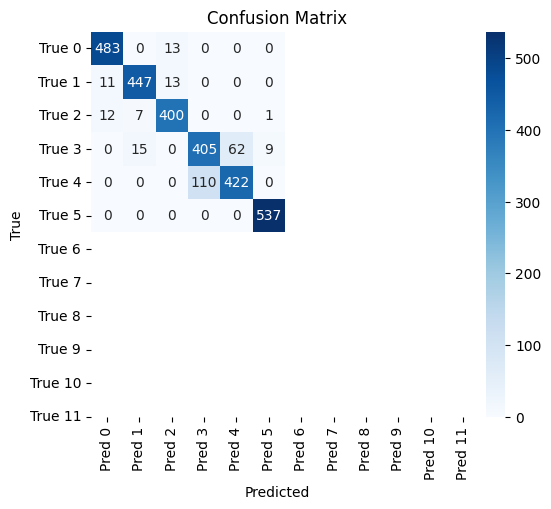

In [11]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        mask = torch.ones(batch_X.size(0), batch_X.size(1)).to(device)
        outputs = model(batch_X, mask, None, None)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = 100.0 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
print("Confusion Matrix:")
print(cm)
print(f"F1 Score: {f1:.4f}")

# 혼동 행렬 시각화
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(config.num_class)],
            yticklabels=[f"True {i}" for i in range(config.num_class)])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [12]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 데이터 로딩 및 전처리
trainy = np.squeeze(trainy)
testy  = np.squeeze(testy)

X_train_tensor = torch.tensor(trainX, dtype=torch.float32)
X_test_tensor  = torch.tensor(testX, dtype=torch.float32)
y_train_tensor = torch.tensor(trainy, dtype=torch.long)
y_test_tensor  = torch.tensor(testy, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 모델 초기화
config = Config()
config.dropout = 0.2  # Dropout 증가
model = Model(config).to(device)
print(model)

# 학습 설정
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
num_epochs = 30

best_val_acc = 0.0
print("Training start...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        mask = torch.ones(batch_X.size(0), batch_X.size(1)).to(device)
        outputs = model(batch_X, mask, None, None)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

    scheduler.step()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    # 검증 단계
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_X, val_y in test_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            mask_val = torch.ones(val_X.size(0), val_X.size(1)).to(device)
            outputs_val = model(val_X, mask_val, None, None)
            loss_val = criterion(outputs_val, val_y)
            running_val_loss += loss_val.item() * val_X.size(0)
            _, predicted_val = torch.max(outputs_val, 1)
            correct_val += (predicted_val == val_y).sum().item()
            total_val += val_y.size(0)

    val_loss = running_val_loss / total_val
    val_acc = 100.0 * correct_val / total_val

    # 체크포인트 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_timesnet.pth")
        print("✅ Best model updated!")

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, " +
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


Model(
  (model): ModuleList(
    (0-2): 3 x TimesBlock(
      (dropout): Dropout(p=0.2, inplace=False)
      (layernorm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (conv): Sequential(
        (0): Inception_Block_V2(
          (conv_branches): ModuleList(
            (0): Sequential(
              (0): Conv2d(64, 256, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
              (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): GELU(approximate='none')
            )
            (1): Sequential(
              (0): Conv2d(64, 256, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2))
              (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): GELU(approximate='none')
            )
            (2): Sequential(
              (0): Conv2d(64, 256, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
              (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affi

Test Accuracy: 92.43%
Confusion Matrix:
[[479   0  17   0   0   0]
 [  0 446  25   0   0   0]
 [  0   0 420   0   0   0]
 [  0   3   0 379  86  23]
 [  0   0   1  68 463   0]
 [  0   0   0   0   0 537]]
F1 Score: 0.9236


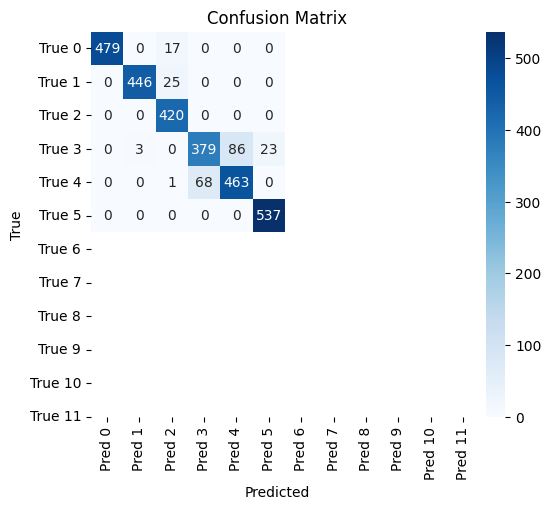

In [13]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        mask = torch.ones(batch_X.size(0), batch_X.size(1)).to(device)
        outputs = model(batch_X, mask, None, None)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = 100.0 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
print("Confusion Matrix:")
print(cm)
print(f"F1 Score: {f1:.4f}")

# 혼동 행렬 시각화
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(config.num_class)],
            yticklabels=[f"True {i}" for i in range(config.num_class)])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()